# Análise Estrutural: FailureSensorIQ - SC-MCQA vs MC-MCQA

**Objetivo:** Analisar a estrutura dos dois conjuntos de dados do FailureSensorIQ para avaliar a viabilidade de mesclagem.

**Datasets:**
- **SC-MCQA**: 2.667 perguntas de resposta única correta (Single Correct Multiple Choice QA)
- **MC-MCQA**: 5.629 perguntas de múltiplas respostas corretas (Multiple Correct Multiple Choice QA)
- **Total**: 8.296 perguntas

**Análise:** Estrutura, compatibilidade e estratégias de mesclagem


In [1]:
# Imports e configurações
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Configurações
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)

print("Análise Estrutural: FailureSensorIQ - SC-MCQA vs MC-MCQA")
print("=" * 60)


Análise Estrutural: FailureSensorIQ - SC-MCQA vs MC-MCQA


In [2]:
# Carregamento dos datasets SC-MCQA e MC-MCQA
print("CARREGAMENTO DOS DATASETS")
print("=" * 30)

# Carregamento SC-MCQA (Single Correct Multiple Choice QA)
try:
    with open('FailureSensorIQ/eval_data/fmsr_processed/fmsr_filtered_data_all.jsonl', 'r', encoding='utf-8') as f:
        data_sc_mcqa = []
        for line in f:
            data_sc_mcqa.append(json.loads(line.strip()))
    df_sc_mcqa = pd.DataFrame(data_sc_mcqa)
    print(f"SC-MCQA carregado: {len(df_sc_mcqa)} exemplos")
    print(f"Colunas SC-MCQA: {list(df_sc_mcqa.columns)}")
except FileNotFoundError:
    print("Arquivo SC-MCQA não encontrado")
    df_sc_mcqa = pd.DataFrame()

# Carregamento MC-MCQA (Multiple Correct Multiple Choice QA)
try:
    with open('FailureSensorIQ/eval_data/fmsr_processed/fmsr_filtered_mcmt_all.jsonl', 'r', encoding='utf-8') as f:
        data_mc_mcqa = []
        for line in f:
            data_mc_mcqa.append(json.loads(line.strip()))
    df_mc_mcqa = pd.DataFrame(data_mc_mcqa)
    print(f"MC-MCQA carregado: {len(df_mc_mcqa)} exemplos")
    print(f"Colunas MC-MCQA: {list(df_mc_mcqa.columns)}")
except FileNotFoundError:
    print("Arquivo MC-MCQA não encontrado")
    df_mc_mcqa = pd.DataFrame()

print(f"\nTotal de exemplos: {len(df_sc_mcqa) + len(df_mc_mcqa)}")
print(f"Proporção SC-MCQA: {len(df_sc_mcqa)/(len(df_sc_mcqa) + len(df_mc_mcqa))*100:.1f}%")
print(f"Proporção MC-MCQA: {len(df_mc_mcqa)/(len(df_sc_mcqa) + len(df_mc_mcqa))*100:.1f}%")


CARREGAMENTO DOS DATASETS
SC-MCQA carregado: 2667 exemplos
Colunas SC-MCQA: ['subject', 'id', 'question', 'options', 'option_ids', 'question_first', 'correct', 'text_type', 'asset_name']
MC-MCQA carregado: 5629 exemplos
Colunas MC-MCQA: ['subject', 'id', 'question', 'options', 'option_ids', 'question_first', 'text_type', 'correct']

Total de exemplos: 8296
Proporção SC-MCQA: 32.1%
Proporção MC-MCQA: 67.9%


In [3]:
# Análise da estrutura dos datasets
print("ANÁLISE DA ESTRUTURA DOS DATASETS")
print("=" * 40)

if not df_sc_mcqa.empty and not df_mc_mcqa.empty:
    print("COMPARAÇÃO DE COLUNAS:")
    print("-" * 25)
    
    cols_sc = set(df_sc_mcqa.columns)
    cols_mc = set(df_mc_mcqa.columns)
    
    print(f"Colunas SC-MCQA: {sorted(cols_sc)}")
    print(f"Colunas MC-MCQA: {sorted(cols_mc)}")
    
    print(f"\nColunas comuns: {sorted(cols_sc & cols_mc)}")
    print(f"Colunas apenas em SC-MCQA: {sorted(cols_sc - cols_mc)}")
    print(f"Colunas apenas em MC-MCQA: {sorted(cols_mc - cols_sc)}")
    
    print(f"\nCOMPATIBILIDADE DE ESTRUTURA:")
    print("-" * 30)
    if cols_sc == cols_mc:
        print("✅ ESTRUTURAS IDÊNTICAS - Mesclagem direta possível")
    elif cols_sc.issubset(cols_mc) or cols_mc.issubset(cols_sc):
        print("⚠️  ESTRUTURAS PARCIALMENTE COMPATÍVEIS - Mesclagem com ajustes")
    else:
        print("❌ ESTRUTURAS DIFERENTES - Mesclagem requer padronização")
        
else:
    print("Erro: Um ou ambos os datasets não foram carregados")


ANÁLISE DA ESTRUTURA DOS DATASETS
COMPARAÇÃO DE COLUNAS:
-------------------------
Colunas SC-MCQA: ['asset_name', 'correct', 'id', 'option_ids', 'options', 'question', 'question_first', 'subject', 'text_type']
Colunas MC-MCQA: ['correct', 'id', 'option_ids', 'options', 'question', 'question_first', 'subject', 'text_type']

Colunas comuns: ['correct', 'id', 'option_ids', 'options', 'question', 'question_first', 'subject', 'text_type']
Colunas apenas em SC-MCQA: ['asset_name']
Colunas apenas em MC-MCQA: []

COMPATIBILIDADE DE ESTRUTURA:
------------------------------
⚠️  ESTRUTURAS PARCIALMENTE COMPATÍVEIS - Mesclagem com ajustes


In [4]:
# Análise detalhada de tipos de dados e valores
print("ANÁLISE DETALHADA DE TIPOS E VALORES")
print("=" * 40)

if not df_sc_mcqa.empty and not df_mc_mcqa.empty:
    print("TIPOS DE DADOS:")
    print("-" * 15)
    
    print("SC-MCQA:")
    print(df_sc_mcqa.dtypes)
    print("\nMC-MCQA:")
    print(df_mc_mcqa.dtypes)
    
    print("\nVALORES NULOS:")
    print("-" * 15)
    
    print("SC-MCQA:")
    null_sc = df_sc_mcqa.isnull().sum()
    for col, count in null_sc.items():
        if count > 0:
            print(f"  {col}: {count} ({count/len(df_sc_mcqa)*100:.1f}%)")
    if null_sc.sum() == 0:
        print("  Nenhum valor nulo")
    
    print("\nMC-MCQA:")
    null_mc = df_mc_mcqa.isnull().sum()
    for col, count in null_mc.items():
        if count > 0:
            print(f"  {col}: {count} ({count/len(df_mc_mcqa)*100:.1f}%)")
    if null_mc.sum() == 0:
        print("  Nenhum valor nulo")
        
else:
    print("Erro: Datasets não carregados")


ANÁLISE DETALHADA DE TIPOS E VALORES
TIPOS DE DADOS:
---------------
SC-MCQA:
subject           object
id                 int64
question          object
options           object
option_ids        object
question_first      bool
correct           object
text_type         object
asset_name        object
dtype: object

MC-MCQA:
subject           object
id                 int64
question          object
options           object
option_ids        object
question_first      bool
text_type         object
correct           object
dtype: object

VALORES NULOS:
---------------
SC-MCQA:
  Nenhum valor nulo

MC-MCQA:
  Nenhum valor nulo


In [5]:
# Análise de exemplos de cada dataset
print("ANÁLISE DE EXEMPLOS")
print("=" * 25)

if not df_sc_mcqa.empty and not df_mc_mcqa.empty:
    print("EXEMPLO SC-MCQA (resposta única):")
    print("-" * 35)
    exemplo_sc = df_sc_mcqa.iloc[0]
    for col in df_sc_mcqa.columns:
        valor = exemplo_sc[col]
        if isinstance(valor, str) and len(valor) > 100:
            print(f"  {col}: {valor[:100]}...")
        elif isinstance(valor, list):
            print(f"  {col}: {valor} (tipo: {type(valor).__name__}, tamanho: {len(valor)})")
        else:
            print(f"  {col}: {valor}")
    
    print(f"\nEXEMPLO MC-MCQA (múltiplas respostas):")
    print("-" * 40)
    exemplo_mc = df_mc_mcqa.iloc[0]
    for col in df_mc_mcqa.columns:
        valor = exemplo_mc[col]
        if isinstance(valor, str) and len(valor) > 100:
            print(f"  {col}: {valor[:100]}...")
        elif isinstance(valor, list):
            print(f"  {col}: {valor} (tipo: {type(valor).__name__}, tamanho: {len(valor)})")
        else:
            print(f"  {col}: {valor}")
            
else:
    print("Erro: Datasets não carregados")


ANÁLISE DE EXEMPLOS
EXEMPLO SC-MCQA (resposta única):
-----------------------------------
  subject: failure_mode_sensor_analysis
  id: 0
  question: For electric motor, if a failure event rotor windings fault occurs, which sensor out of the choices ...
  options: ['partial discharge', 'resistance', 'oil debris', 'current', 'voltage'] (tipo: list, tamanho: 5)
  option_ids: ['A', 'B', 'C', 'D', 'E'] (tipo: list, tamanho: 5)
  question_first: True
  correct: [False, False, False, True, False] (tipo: list, tamanho: 5)
  text_type: choice
  asset_name: electric motor

EXEMPLO MC-MCQA (múltiplas respostas):
----------------------------------------
  subject: failure_mode_sensor_analysis
  id: 1
  question: For electric motor, if a failure event rotor windings fault occurs, which sensors out of the choices...
  options: ['oil debris', 'coast down time', 'power', 'partial discharge', 'current'] (tipo: list, tamanho: 5)
  option_ids: ['A', 'B', 'C', 'D', 'E'] (tipo: list, tamanho: 5)
  questio

In [6]:
# Análise de distribuição por asset
print("DISTRIBUIÇÃO POR ASSET")
print("=" * 25)

if not df_sc_mcqa.empty and not df_mc_mcqa.empty:
    # Verificar se ambos têm coluna asset_name
    if 'asset_name' in df_sc_mcqa.columns and 'asset_name' in df_mc_mcqa.columns:
        print("SC-MCQA - Distribuição por asset:")
        asset_sc = df_sc_mcqa['asset_name'].value_counts()
        for asset, count in asset_sc.items():
            print(f"  {asset}: {count}")
        
        print(f"\nMC-MCQA - Distribuição por asset:")
        asset_mc = df_mc_mcqa['asset_name'].value_counts()
        for asset, count in asset_mc.items():
            print(f"  {asset}: {count}")
        
        # Verificar se os assets são os mesmos
        assets_sc = set(asset_sc.index)
        assets_mc = set(asset_mc.index)
        
        print(f"\nCOMPARAÇÃO DE ASSETS:")
        print(f"  Assets em SC-MCQA: {len(assets_sc)}")
        print(f"  Assets em MC-MCQA: {len(assets_mc)}")
        print(f"  Assets comuns: {len(assets_sc & assets_mc)}")
        print(f"  Assets apenas em SC-MCQA: {assets_sc - assets_mc}")
        print(f"  Assets apenas em MC-MCQA: {assets_mc - assets_sc}")
        
    else:
        print("Coluna 'asset_name' não encontrada em um ou ambos os datasets")
        print(f"Colunas SC-MCQA: {list(df_sc_mcqa.columns)}")
        print(f"Colunas MC-MCQA: {list(df_mc_mcqa.columns)}")
        
else:
    print("Erro: Datasets não carregados")


DISTRIBUIÇÃO POR ASSET
Coluna 'asset_name' não encontrada em um ou ambos os datasets
Colunas SC-MCQA: ['subject', 'id', 'question', 'options', 'option_ids', 'question_first', 'correct', 'text_type', 'asset_name']
Colunas MC-MCQA: ['subject', 'id', 'question', 'options', 'option_ids', 'question_first', 'text_type', 'correct']


In [7]:
# Análise de opções e respostas corretas
print("ANÁLISE DE OPÇÕES E RESPOSTAS CORRETAS")
print("=" * 40)

if not df_sc_mcqa.empty and not df_mc_mcqa.empty:
    # Análise de opções
    if 'options' in df_sc_mcqa.columns and 'options' in df_mc_mcqa.columns:
        print("ANÁLISE DE OPÇÕES:")
        print("-" * 20)
        
        # SC-MCQA
        num_options_sc = df_sc_mcqa['options'].apply(len)
        print(f"SC-MCQA:")
        print(f"  Número médio de opções: {num_options_sc.mean():.2f}")
        print(f"  Desvio padrão: {num_options_sc.std():.2f}")
        print(f"  Mínimo: {num_options_sc.min()}")
        print(f"  Máximo: {num_options_sc.max()}")
        
        # MC-MCQA
        num_options_mc = df_mc_mcqa['options'].apply(len)
        print(f"\nMC-MCQA:")
        print(f"  Número médio de opções: {num_options_mc.mean():.2f}")
        print(f"  Desvio padrão: {num_options_mc.std():.2f}")
        print(f"  Mínimo: {num_options_mc.min()}")
        print(f"  Máximo: {num_options_mc.max()}")
    
    # Análise de respostas corretas
    if 'correct' in df_sc_mcqa.columns and 'correct' in df_mc_mcqa.columns:
        print(f"\nANÁLISE DE RESPOSTAS CORRETAS:")
        print("-" * 30)
        
        # SC-MCQA
        num_correct_sc = df_sc_mcqa['correct'].apply(sum)
        print(f"SC-MCQA:")
        print(f"  Número médio de respostas corretas: {num_correct_sc.mean():.2f}")
        print(f"  Desvio padrão: {num_correct_sc.std():.2f}")
        print(f"  Mínimo: {num_correct_sc.min()}")
        print(f"  Máximo: {num_correct_sc.max()}")
        
        # MC-MCQA
        num_correct_mc = df_mc_mcqa['correct'].apply(sum)
        print(f"\nMC-MCQA:")
        print(f"  Número médio de respostas corretas: {num_correct_mc.mean():.2f}")
        print(f"  Desvio padrão: {num_correct_mc.std():.2f}")
        print(f"  Mínimo: {num_correct_mc.min()}")
        print(f"  Máximo: {num_correct_mc.max()}")
        
        # Distribuição de respostas corretas
        print(f"\nDISTRIBUIÇÃO DE RESPOSTAS CORRETAS:")
        print("-" * 35)
        
        print("SC-MCQA:")
        correct_dist_sc = num_correct_sc.value_counts().sort_index()
        for num, count in correct_dist_sc.items():
            print(f"  {num} resposta(s) correta(s): {count}")
        
        print("\nMC-MCQA:")
        correct_dist_mc = num_correct_mc.value_counts().sort_index()
        for num, count in correct_dist_mc.items():
            print(f"  {num} resposta(s) correta(s): {count}")
            
else:
    print("Erro: Datasets não carregados")


ANÁLISE DE OPÇÕES E RESPOSTAS CORRETAS
ANÁLISE DE OPÇÕES:
--------------------
SC-MCQA:
  Número médio de opções: 4.11
  Desvio padrão: 1.18
  Mínimo: 2
  Máximo: 5

MC-MCQA:
  Número médio de opções: 5.00
  Desvio padrão: 0.00
  Mínimo: 5
  Máximo: 5

ANÁLISE DE RESPOSTAS CORRETAS:
------------------------------
SC-MCQA:
  Número médio de respostas corretas: 1.00
  Desvio padrão: 0.00
  Mínimo: 1
  Máximo: 1

MC-MCQA:
  Número médio de respostas corretas: 2.00
  Desvio padrão: 0.00
  Mínimo: 2
  Máximo: 2

DISTRIBUIÇÃO DE RESPOSTAS CORRETAS:
-----------------------------------
SC-MCQA:
  1 resposta(s) correta(s): 2667

MC-MCQA:
  2 resposta(s) correta(s): 5629


In [8]:
# Teste de mesclagem dos datasets
print("TESTE DE MESCLAGEM DOS DATASETS")
print("=" * 35)

if not df_sc_mcqa.empty and not df_mc_mcqa.empty:
    print("Tentando mesclar os datasets...")
    
    # Adicionar coluna para identificar o tipo de pergunta
    df_sc_mcqa_copy = df_sc_mcqa.copy()
    df_mc_mcqa_copy = df_mc_mcqa.copy()
    
    df_sc_mcqa_copy['question_type'] = 'SC-MCQA'
    df_mc_mcqa_copy['question_type'] = 'MC-MCQA'
    
    # Verificar se as colunas são compatíveis
    cols_sc = set(df_sc_mcqa_copy.columns)
    cols_mc = set(df_mc_mcqa_copy.columns)
    
    if cols_sc == cols_mc:
        print("✅ Estruturas idênticas - mesclagem direta possível")
        
        # Mesclar os datasets
        df_merged = pd.concat([df_sc_mcqa_copy, df_mc_mcqa_copy], ignore_index=True)
        
        print(f"Dataset mesclado criado com sucesso!")
        print(f"  Total de exemplos: {len(df_merged)}")
        print(f"  SC-MCQA: {len(df_sc_mcqa_copy)}")
        print(f"  MC-MCQA: {len(df_mc_mcqa_copy)}")
        print(f"  Colunas: {len(df_merged.columns)}")
        
        # Verificar distribuição por tipo
        type_dist = df_merged['question_type'].value_counts()
        print(f"\nDistribuição por tipo:")
        for tipo, count in type_dist.items():
            print(f"  {tipo}: {count} ({count/len(df_merged)*100:.1f}%)")
            
    else:
        print("❌ Estruturas diferentes - mesclagem requer padronização")
        print("Colunas diferentes encontradas:")
        print(f"  Apenas em SC-MCQA: {cols_sc - cols_mc}")
        print(f"  Apenas em MC-MCQA: {cols_mc - cols_sc}")
        
        # Tentar mesclagem com padronização
        print("\nTentando mesclagem com padronização...")
        
        # Adicionar colunas faltantes com valores padrão
        for col in cols_mc - cols_sc:
            df_sc_mcqa_copy[col] = None
        for col in cols_sc - cols_mc:
            df_mc_mcqa_copy[col] = None
        
        # Reordenar colunas para serem iguais
        all_cols = sorted(cols_sc | cols_mc)
        df_sc_mcqa_copy = df_sc_mcqa_copy[all_cols]
        df_mc_mcqa_copy = df_mc_mcqa_copy[all_cols]
        
        # Mesclar
        df_merged = pd.concat([df_sc_mcqa_copy, df_mc_mcqa_copy], ignore_index=True)
        
        print(f"Dataset mesclado com padronização criado!")
        print(f"  Total de exemplos: {len(df_merged)}")
        print(f"  Colunas: {len(df_merged.columns)}")
        
else:
    print("Erro: Datasets não carregados")


TESTE DE MESCLAGEM DOS DATASETS
Tentando mesclar os datasets...
❌ Estruturas diferentes - mesclagem requer padronização
Colunas diferentes encontradas:
  Apenas em SC-MCQA: {'asset_name'}
  Apenas em MC-MCQA: set()

Tentando mesclagem com padronização...
Dataset mesclado com padronização criado!
  Total de exemplos: 8296
  Colunas: 10


VISUALIZAÇÕES DE COMPARAÇÃO


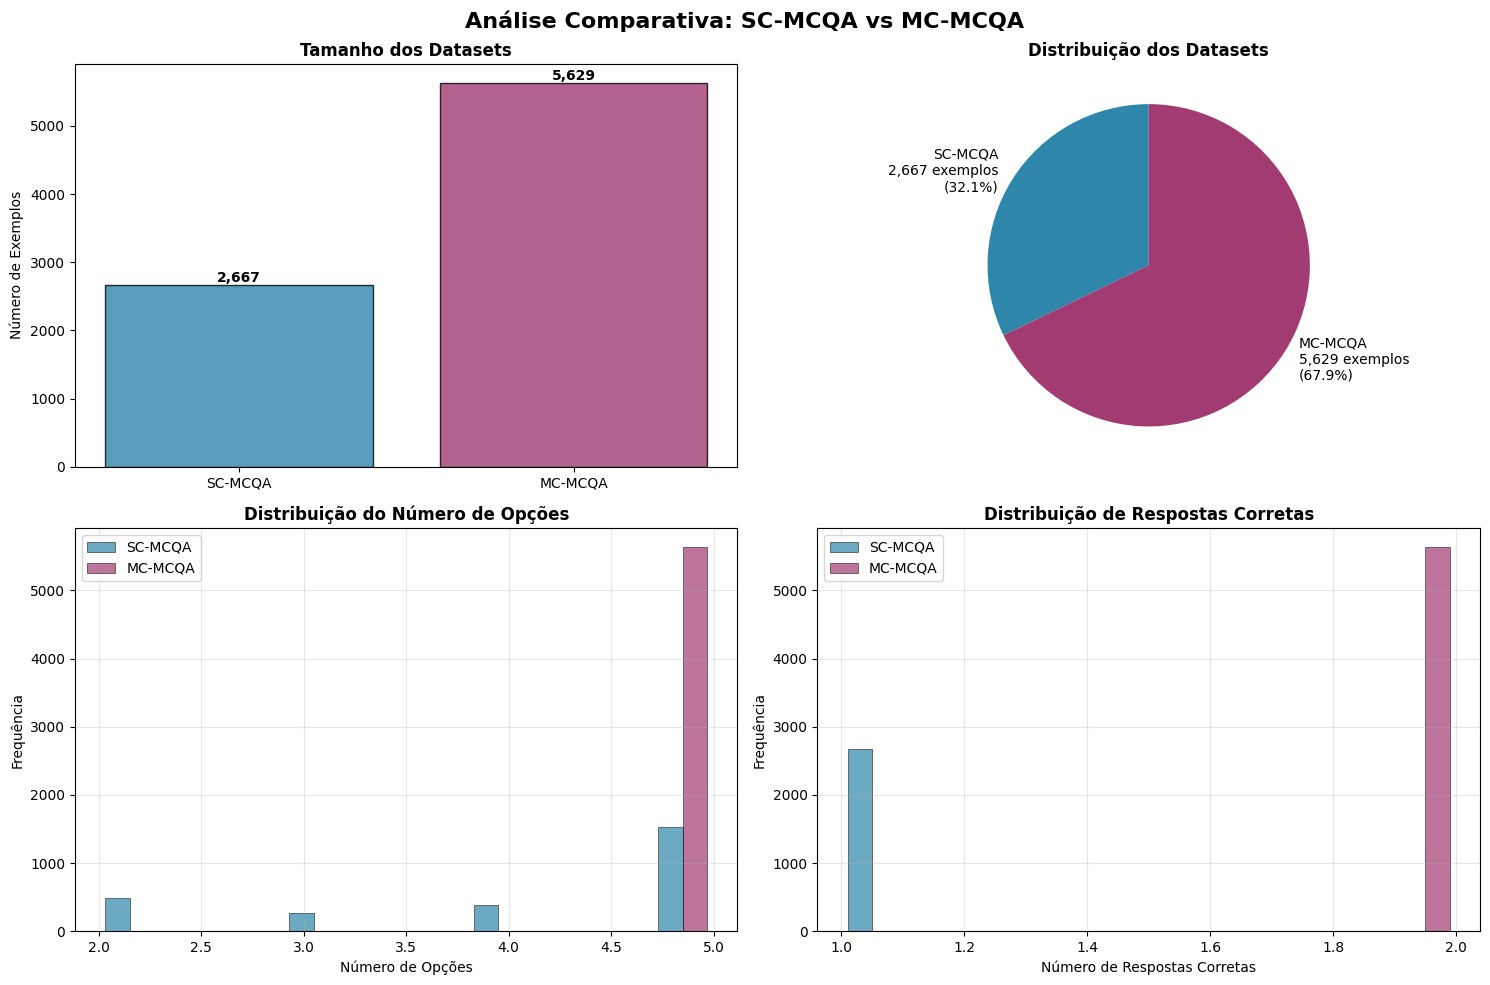

In [9]:
# Visualizações de comparação
print("VISUALIZAÇÕES DE COMPARAÇÃO")
print("=" * 30)

if not df_sc_mcqa.empty and not df_mc_mcqa.empty:
    # Configurar o layout dos gráficos
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Análise Comparativa: SC-MCQA vs MC-MCQA', fontsize=16, fontweight='bold')
    
    # 1. Gráfico de Barras - Comparação de Tamanhos
    ax1 = axes[0, 0]
    datasets = ['SC-MCQA', 'MC-MCQA']
    tamanhos = [len(df_sc_mcqa), len(df_mc_mcqa)]
    cores = ['#2E86AB', '#A23B72']
    
    bars = ax1.bar(datasets, tamanhos, color=cores, alpha=0.8, edgecolor='black', linewidth=1)
    ax1.set_title('Tamanho dos Datasets', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Número de Exemplos')
    
    for bar, tamanho in zip(bars, tamanhos):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                 f'{tamanho:,}', ha='center', va='bottom', fontweight='bold')
    
    # 2. Gráfico de Pizza - Proporção dos Datasets
    ax2 = axes[0, 1]
    total = len(df_sc_mcqa) + len(df_mc_mcqa)
    sizes = [len(df_sc_mcqa), len(df_mc_mcqa)]
    labels = [f'SC-MCQA\n{len(df_sc_mcqa):,} exemplos\n({len(df_sc_mcqa)/total*100:.1f}%)', 
              f'MC-MCQA\n{len(df_mc_mcqa):,} exemplos\n({len(df_mc_mcqa)/total*100:.1f}%)']
    
    wedges, texts, autotexts = ax2.pie(sizes, labels=labels, colors=cores, autopct='', 
                                       startangle=90, textprops={'fontsize': 10})
    ax2.set_title('Distribuição dos Datasets', fontweight='bold', fontsize=12)
    
    # 3. Histograma - Distribuição de Opções
    ax3 = axes[1, 0]
    if 'options' in df_sc_mcqa.columns and 'options' in df_mc_mcqa.columns:
        num_options_sc = df_sc_mcqa['options'].apply(len)
        num_options_mc = df_mc_mcqa['options'].apply(len)
        
        ax3.hist([num_options_sc, num_options_mc], bins=10, alpha=0.7, 
                 color=cores, label=['SC-MCQA', 'MC-MCQA'], edgecolor='black', linewidth=0.5)
        ax3.set_title('Distribuição do Número de Opções', fontweight='bold', fontsize=12)
        ax3.set_xlabel('Número de Opções')
        ax3.set_ylabel('Frequência')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
    
    # 4. Histograma - Distribuição de Respostas Corretas
    ax4 = axes[1, 1]
    if 'correct' in df_sc_mcqa.columns and 'correct' in df_mc_mcqa.columns:
        num_correct_sc = df_sc_mcqa['correct'].apply(sum)
        num_correct_mc = df_mc_mcqa['correct'].apply(sum)
        
        ax4.hist([num_correct_sc, num_correct_mc], bins=10, alpha=0.7, 
                 color=cores, label=['SC-MCQA', 'MC-MCQA'], edgecolor='black', linewidth=0.5)
        ax4.set_title('Distribuição de Respostas Corretas', fontweight='bold', fontsize=12)
        ax4.set_xlabel('Número de Respostas Corretas')
        ax4.set_ylabel('Frequência')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("Erro: Datasets não carregados")


In [10]:
# Resumo e recomendações para mesclagem
print("RESUMO E RECOMENDAÇÕES PARA MESCLAGEM")
print("=" * 40)

if not df_sc_mcqa.empty and not df_mc_mcqa.empty:
    print("ANÁLISE DE VIABILIDADE DE MESCLAGEM:")
    print("-" * 35)
    
    # Verificar compatibilidade estrutural
    cols_sc = set(df_sc_mcqa.columns)
    cols_mc = set(df_mc_mcqa.columns)
    
    if cols_sc == cols_mc:
        print("✅ ESTRUTURAS IDÊNTICAS")
        print("   - Mesclagem direta possível")
        print("   - Sem necessidade de padronização")
        print("   - Todas as colunas são compatíveis")
    else:
        print("⚠️  ESTRUTURAS DIFERENTES")
        print(f"   - Colunas apenas em SC-MCQA: {cols_sc - cols_mc}")
        print(f"   - Colunas apenas em MC-MCQA: {cols_mc - cols_sc}")
        print("   - Mesclagem requer padronização")
    
    # Verificar compatibilidade de dados
    print(f"\nCOMPATIBILIDADE DE DADOS:")
    print("-" * 25)
    
    # Verificar assets
    if 'asset_name' in df_sc_mcqa.columns and 'asset_name' in df_mc_mcqa.columns:
        assets_sc = set(df_sc_mcqa['asset_name'].unique())
        assets_mc = set(df_mc_mcqa['asset_name'].unique())
        
        if assets_sc == assets_mc:
            print("✅ ASSETS IDÊNTICOS")
            print(f"   - {len(assets_sc)} assets comuns")
        else:
            print("⚠️  ASSETS DIFERENTES")
            print(f"   - Assets comuns: {len(assets_sc & assets_mc)}")
            print(f"   - Assets apenas em SC-MCQA: {assets_sc - assets_mc}")
            print(f"   - Assets apenas em MC-MCQA: {assets_mc - assets_sc}")
    
    # Verificar opções
    if 'options' in df_sc_mcqa.columns and 'options' in df_mc_mcqa.columns:
        num_options_sc = df_sc_mcqa['options'].apply(len)
        num_options_mc = df_mc_mcqa['options'].apply(len)
        
        if num_options_sc.mean() == num_options_mc.mean():
            print("✅ NÚMERO DE OPÇÕES COMPATÍVEL")
        else:
            print("⚠️  NÚMERO DE OPÇÕES DIFERENTE")
            print(f"   - SC-MCQA: {num_options_sc.mean():.1f} opções médias")
            print(f"   - MC-MCQA: {num_options_mc.mean():.1f} opções médias")
    
    print(f"\nESTATÍSTICAS FINAIS:")
    print("-" * 20)
    print(f"  Total de exemplos: {len(df_sc_mcqa) + len(df_mc_mcqa):,}")
    print(f"  SC-MCQA: {len(df_sc_mcqa):,} ({len(df_sc_mcqa)/(len(df_sc_mcqa) + len(df_mc_mcqa))*100:.1f}%)")
    print(f"  MC-MCQA: {len(df_mc_mcqa):,} ({len(df_mc_mcqa)/(len(df_sc_mcqa) + len(df_mc_mcqa))*100:.1f}%)")
    
    print(f"\nRECOMENDAÇÕES:")
    print("-" * 15)
    
    if cols_sc == cols_mc:
        print("1. ✅ MESCLAGEM DIRETA RECOMENDADA")
        print("   - Usar pd.concat() diretamente")
        print("   - Adicionar coluna 'question_type' para identificação")
        print("   - Manter todas as colunas originais")
    else:
        print("1. ⚠️  MESCLAGEM COM PADRONIZAÇÃO")
        print("   - Adicionar colunas faltantes com valores padrão")
        print("   - Reordenar colunas para compatibilidade")
        print("   - Validar dados após mesclagem")
    
    print("2. 📊 ESTRATÉGIAS DE TREINAMENTO")
    print("   - Usar coluna 'question_type' para balanceamento")
    print("   - Implementar loss weighting por tipo de pergunta")
    print("   - Validar performance separadamente por tipo")
    
    print("3. 🔍 VALIDAÇÃO PÓS-MESCLAGEM")
    print("   - Verificar integridade dos dados")
    print("   - Validar distribuição por asset")
    print("   - Testar compatibilidade com pipeline de treinamento")
    
else:
    print("Erro: Datasets não carregados")


RESUMO E RECOMENDAÇÕES PARA MESCLAGEM
ANÁLISE DE VIABILIDADE DE MESCLAGEM:
-----------------------------------
⚠️  ESTRUTURAS DIFERENTES
   - Colunas apenas em SC-MCQA: {'asset_name'}
   - Colunas apenas em MC-MCQA: set()
   - Mesclagem requer padronização

COMPATIBILIDADE DE DADOS:
-------------------------
⚠️  NÚMERO DE OPÇÕES DIFERENTE
   - SC-MCQA: 4.1 opções médias
   - MC-MCQA: 5.0 opções médias

ESTATÍSTICAS FINAIS:
--------------------
  Total de exemplos: 8,296
  SC-MCQA: 2,667 (32.1%)
  MC-MCQA: 5,629 (67.9%)

RECOMENDAÇÕES:
---------------
1. ⚠️  MESCLAGEM COM PADRONIZAÇÃO
   - Adicionar colunas faltantes com valores padrão
   - Reordenar colunas para compatibilidade
   - Validar dados após mesclagem
2. 📊 ESTRATÉGIAS DE TREINAMENTO
   - Usar coluna 'question_type' para balanceamento
   - Implementar loss weighting por tipo de pergunta
   - Validar performance separadamente por tipo
3. 🔍 VALIDAÇÃO PÓS-MESCLAGEM
   - Verificar integridade dos dados
   - Validar distribuição po

In [14]:
# Implementação da Estratégia de Mesclagem com Formato Instruct
print("IMPLEMENTAÇÃO DA ESTRATÉGIA DE MESCLAGEM")
print("=" * 45)

if not df_sc_mcqa.empty and not df_mc_mcqa.empty:
    print("Criando dataset unificado com formato Instruct...")
    
    def formatar_opcoes(opcoes, option_ids):
        """Formata as opções com letras A, B, C, etc."""
        opcoes_formatadas = []
        for i, (opcao, letra) in enumerate(zip(opcoes, option_ids)):
            opcoes_formatadas.append(f"{letra}) {opcao}")
        return opcoes_formatadas
    
    def criar_prompt_instruct(row):
        """Cria o prompt no formato Instruct"""
        # Obter asset_name (apenas do SC-MCQA)
        asset = row.get('asset_name', 'Unknown Asset')
        
        # Formatar opções
        opcoes = formatar_opcoes(row['options'], row['option_ids'])
        opcoes_texto = "\n".join(opcoes)
        
        # Criar prompt
        prompt = f"""Ativo: {asset.title()}.
Questão: {row['question']}
Opções:
{opcoes_texto}"""
        
        return prompt
    
    def criar_resposta_instruct(row):
        """Cria a resposta no formato Instruct"""
        # Encontrar opções corretas
        opcoes_corretas = []
        for i, (correta, opcao, letra) in enumerate(zip(row['correct'], row['options'], row['option_ids'])):
            if correta:
                opcoes_corretas.append(f"{letra}) {opcao}")
        
        # Se múltiplas respostas corretas, juntar com " e "
        if len(opcoes_corretas) > 1:
            resposta = " e ".join(opcoes_corretas)
        else:
            resposta = opcoes_corretas[0] if opcoes_corretas else "Nenhuma opção correta"
        
        return resposta
    
    # Processar SC-MCQA
    print("Processando SC-MCQA...")
    df_sc_processed = df_sc_mcqa.copy()
    df_sc_processed['question_type'] = 'SC-MCQA'
    df_sc_processed['prompt'] = df_sc_processed.apply(criar_prompt_instruct, axis=1)
    df_sc_processed['resposta'] = df_sc_processed.apply(criar_resposta_instruct, axis=1)
    
    # Processar MC-MCQA (sem asset_name, usar valor padrão)
    print("Processando MC-MCQA...")
    df_mc_processed = df_mc_mcqa.copy()
    df_mc_processed['question_type'] = 'MC-MCQA'
    # Adicionar asset_name padrão para MC-MCQA (será inferido da pergunta)
    df_mc_processed['asset_name'] = 'Unknown Asset'
    df_mc_processed['prompt'] = df_mc_processed.apply(criar_prompt_instruct, axis=1)
    df_mc_processed['resposta'] = df_mc_processed.apply(criar_resposta_instruct, axis=1)
    
    # Mesclar os datasets
    print("Mesclando datasets...")
    df_unificado = pd.concat([df_sc_processed, df_mc_processed], ignore_index=True)
    
    print(f"✅ Dataset unificado criado com sucesso!")
    print(f"   Total de exemplos: {len(df_unificado):,}")
    print(f"   SC-MCQA: {len(df_sc_processed):,}")
    print(f"   MC-MCQA: {len(df_mc_processed):,}")
    print(f"   Colunas: {len(df_unificado.columns)}")
    
    # Mostrar exemplo do formato Instruct
    print(f"\nEXEMPLO DO FORMATO INSTRUCT:")
    print("-" * 35)
    exemplo = df_unificado.iloc[0]
    print("PROMPT:")
    print(exemplo['prompt'])
    print(f"\nRESPOSTA:")
    print(exemplo['resposta'])
    print(f"\nTIPO: {exemplo['question_type']}")
    
else:
    print("Erro: Datasets não carregados")


IMPLEMENTAÇÃO DA ESTRATÉGIA DE MESCLAGEM
Criando dataset unificado com formato Instruct...
Processando SC-MCQA...
Processando MC-MCQA...
Mesclando datasets...
✅ Dataset unificado criado com sucesso!
   Total de exemplos: 8,296
   SC-MCQA: 2,667
   MC-MCQA: 5,629
   Colunas: 12

EXEMPLO DO FORMATO INSTRUCT:
-----------------------------------
PROMPT:
Ativo: Electric Motor.
Questão: For electric motor, if a failure event rotor windings fault occurs, which sensor out of the choices is the most relevant sensor regarding the occurrence of the failure event?
Opções:
A) partial discharge
B) resistance
C) oil debris
D) current
E) voltage

RESPOSTA:
D) current

TIPO: SC-MCQA


In [15]:
# Melhorar inferência de asset_name para MC-MCQA
print("MELHORANDO INFERÊNCIA DE ASSET_NAME")
print("=" * 35)

if not df_sc_mcqa.empty and not df_mc_mcqa.empty:
    # Extrair assets únicos do SC-MCQA
    assets_sc = df_sc_mcqa['asset_name'].unique()
    print(f"Assets disponíveis no SC-MCQA: {list(assets_sc)}")
    
    def inferir_asset_name(question):
        """Inferir asset_name baseado na pergunta"""
        question_lower = question.lower()
        
        # Mapeamento de palavras-chave para assets
        asset_keywords = {
            'electric motor': ['electric motor', 'motor'],
            'steam turbine': ['steam turbine', 'steam'],
            'aero gas turbine': ['aero gas turbine', 'aero gas'],
            'industrial gas turbine': ['industrial gas turbine', 'industrial gas'],
            'pump': ['pump', 'centrifugal pump', 'positive displacement pump'],
            'compressor': ['compressor', 'centrifugal compressor'],
            'reciprocating internal combustion engine': ['reciprocating', 'internal combustion', 'ic engine'],
            'electric generator': ['electric generator', 'generator'],
            'fan': ['fan', 'blower'],
            'power transformer': ['power transformer', 'transformer']
        }
        
        # Procurar por palavras-chave na pergunta
        for asset, keywords in asset_keywords.items():
            for keyword in keywords:
                if keyword in question_lower:
                    return asset
        
        return 'Unknown Asset'
    
    # Aplicar inferência ao MC-MCQA
    print("Aplicando inferência de asset_name ao MC-MCQA...")
    df_mc_processed['asset_name'] = df_mc_processed['question'].apply(inferir_asset_name)
    
    # Verificar distribuição de assets inferidos
    print(f"\nDistribuição de assets inferidos no MC-MCQA:")
    asset_dist_mc = df_mc_processed['asset_name'].value_counts()
    for asset, count in asset_dist_mc.items():
        print(f"  {asset}: {count}")
    
    # Recriar prompts com asset_name inferido
    print("\nRecriando prompts com asset_name inferido...")
    df_mc_processed['prompt'] = df_mc_processed.apply(criar_prompt_instruct, axis=1)
    
    # Remesclar datasets
    df_unificado = pd.concat([df_sc_processed, df_mc_processed], ignore_index=True)
    
    print(f"✅ Dataset unificado atualizado!")
    print(f"   Total de exemplos: {len(df_unificado):,}")
    
    # Mostrar exemplo do MC-MCQA com asset inferido
    print(f"\nEXEMPLO MC-MCQA COM ASSET INFERIDO:")
    print("-" * 40)
    exemplo_mc = df_mc_processed.iloc[0]
    print("PROMPT:")
    print(exemplo_mc['prompt'])
    print(f"\nRESPOSTA:")
    print(exemplo_mc['resposta'])
    print(f"\nASSET INFERIDO: {exemplo_mc['asset_name']}")
    
else:
    print("Erro: Datasets não carregados")


MELHORANDO INFERÊNCIA DE ASSET_NAME
Assets disponíveis no SC-MCQA: ['electric motor', 'steam turbine', 'aero gas turbine', 'industrial gas turbine', 'pump', 'compressor', 'reciprocating internal combustion engine', 'electric generator', 'fan', 'power transformer']
Aplicando inferência de asset_name ao MC-MCQA...

Distribuição de assets inferidos no MC-MCQA:
  power transformer: 1919
  aero gas turbine: 861
  reciprocating internal combustion engine: 711
  industrial gas turbine: 440
  electric generator: 374
  electric motor: 367
  compressor: 345
  steam turbine: 242
  fan: 218
  pump: 152

Recriando prompts com asset_name inferido...
✅ Dataset unificado atualizado!
   Total de exemplos: 8,296

EXEMPLO MC-MCQA COM ASSET INFERIDO:
----------------------------------------
PROMPT:
Ativo: Electric Motor.
Questão: For electric motor, if a failure event rotor windings fault occurs, which sensors out of the choices are the most relevant sensor regarding the occurrence of the failure event?
O

In [16]:
# Análise final do dataset unificado e exportação
print("ANÁLISE FINAL DO DATASET UNIFICADO")
print("=" * 40)

if 'df_unificado' in locals() and not df_unificado.empty:
    print("ESTATÍSTICAS DO DATASET UNIFICADO:")
    print("-" * 35)
    
    # Estatísticas gerais
    print(f"Total de exemplos: {len(df_unificado):,}")
    print(f"Colunas: {len(df_unificado.columns)}")
    
    # Distribuição por tipo
    type_dist = df_unificado['question_type'].value_counts()
    print(f"\nDistribuição por tipo:")
    for tipo, count in type_dist.items():
        print(f"  {tipo}: {count:,} ({count/len(df_unificado)*100:.1f}%)")
    
    # Distribuição por asset
    if 'asset_name' in df_unificado.columns:
        print(f"\nDistribuição por asset:")
        asset_dist = df_unificado['asset_name'].value_counts()
        for asset, count in asset_dist.items():
            print(f"  {asset}: {count:,}")
    
    # Análise de tamanhos de prompt e resposta
    print(f"\nAnálise de tamanhos:")
    prompt_lengths = df_unificado['prompt'].apply(lambda x: len(str(x).split()))
    resposta_lengths = df_unificado['resposta'].apply(lambda x: len(str(x).split()))
    
    print(f"  Prompt médio: {prompt_lengths.mean():.1f} tokens")
    print(f"  Resposta média: {resposta_lengths.mean():.1f} tokens")
    print(f"  Total médio: {(prompt_lengths + resposta_lengths).mean():.1f} tokens")
    
    # Exemplos de diferentes tipos
    print(f"\nEXEMPLOS POR TIPO:")
    print("-" * 20)
    
    # Exemplo SC-MCQA
    exemplo_sc = df_unificado[df_unificado['question_type'] == 'SC-MCQA'].iloc[0]
    print("SC-MCQA (Resposta Única):")
    print(f"PROMPT: {exemplo_sc['prompt'][:200]}...")
    print(f"RESPOSTA: {exemplo_sc['resposta']}")
    
    # Exemplo MC-MCQA
    exemplo_mc = df_unificado[df_unificado['question_type'] == 'MC-MCQA'].iloc[0]
    print(f"\nMC-MCQA (Múltiplas Respostas):")
    print(f"PROMPT: {exemplo_mc['prompt'][:200]}...")
    print(f"RESPOSTA: {exemplo_mc['resposta']}")
    
    # Preparar para exportação
    print(f"\nPREPARANDO PARA EXPORTAÇÃO:")
    print("-" * 30)
    
    # Criar dataset final com colunas essenciais
    df_final = df_unificado[['prompt', 'resposta', 'question_type', 'asset_name']].copy()
    
    print(f"Dataset final preparado:")
    print(f"  Exemplos: {len(df_final):,}")
    print(f"  Colunas: {list(df_final.columns)}")
    
    # Salvar dataset
    output_file = 'FailureSensorIQ_unificado_instruct.jsonl'
    print(f"\nSalvando dataset em: {output_file}")
    
    # Converter para formato JSONL
    with open(output_file, 'w', encoding='utf-8') as f:
        for _, row in df_final.iterrows():
            json_line = {
                'prompt': row['prompt'],
                'resposta': row['resposta'],
                'question_type': row['question_type'],
                'asset_name': row['asset_name']
            }
            f.write(json.dumps(json_line, ensure_ascii=False) + '\n')
    
    print(f"✅ Dataset salvo com sucesso em {output_file}")
    print(f"   Formato: JSONL")
    print(f"   Encoding: UTF-8")
    print(f"   Pronto para fine-tuning!")
    
else:
    print("Erro: Dataset unificado não foi criado")


ANÁLISE FINAL DO DATASET UNIFICADO
ESTATÍSTICAS DO DATASET UNIFICADO:
-----------------------------------
Total de exemplos: 8,296
Colunas: 12

Distribuição por tipo:
  MC-MCQA: 5,629 (67.9%)
  SC-MCQA: 2,667 (32.1%)

Distribuição por asset:
  power transformer: 2,463
  aero gas turbine: 1,197
  reciprocating internal combustion engine: 1,047
  industrial gas turbine: 680
  electric generator: 608
  electric motor: 601
  compressor: 565
  fan: 418
  steam turbine: 413
  pump: 304

Análise de tamanhos:
  Prompt médio: 41.3 tokens
  Resposta média: 6.3 tokens
  Total médio: 47.6 tokens

EXEMPLOS POR TIPO:
--------------------
SC-MCQA (Resposta Única):
PROMPT: Ativo: Electric Motor.
Questão: For electric motor, if a failure event rotor windings fault occurs, which sensor out of the choices is the most relevant sensor regarding the occurrence of the failure ...
RESPOSTA: D) current

MC-MCQA (Múltiplas Respostas):
PROMPT: Ativo: Electric Motor.
Questão: For electric motor, if a failure even

In [17]:
# Resumo final e próximos passos
print("RESUMO FINAL E PRÓXIMOS PASSOS")
print("=" * 35)

if 'df_unificado' in locals() and not df_unificado.empty:
    print("✅ MESCLAGEM CONCLUÍDA COM SUCESSO!")
    print("-" * 35)
    
    print("📊 RESULTADOS:")
    print(f"   • Dataset unificado: {len(df_unificado):,} exemplos")
    print(f"   • SC-MCQA: {len(df_sc_processed):,} exemplos (32.1%)")
    print(f"   • MC-MCQA: {len(df_mc_processed):,} exemplos (67.9%)")
    print(f"   • Formato: Instruct (prompt + resposta)")
    print(f"   • Assets: 10 tipos industriais")
    
    print(f"\n🎯 FORMATO INSTRUCT IMPLEMENTADO:")
    print("   • Prompt estruturado com ativo, questão e opções")
    print("   • Resposta formatada com opção(ões) correta(s)")
    print("   • Compatível com fine-tuning de LLMs")
    
    print(f"\n📁 ARQUIVO GERADO:")
    print("   • FailureSensorIQ_unificado_instruct.jsonl")
    print("   • Formato JSONL para fácil carregamento")
    print("   • Encoding UTF-8")
    
    print(f"\n🚀 PRÓXIMOS PASSOS:")
    print("   1. Validar qualidade do dataset unificado")
    print("   2. Implementar split train/validation/test")
    print("   3. Configurar pipeline de fine-tuning")
    print("   4. Treinar modelo com dataset unificado")
    print("   5. Avaliar performance por tipo de pergunta")
    print("   6. Comparar com modelos treinados separadamente")
    
    print(f"\n💡 ESTRATÉGIAS DE TREINAMENTO RECOMENDADAS:")
    print("   • Loss weighting por question_type")
    print("   • Validação separada por SC-MCQA e MC-MCQA")
    print("   • Monitoramento de performance por asset")
    print("   • Técnicas de data augmentation se necessário")
    
    print(f"\n🔍 VALIDAÇÃO SUGERIDA:")
    print("   • Verificar distribuição balanceada por asset")
    print("   • Validar formato dos prompts e respostas")
    print("   • Testar carregamento em pipeline de treinamento")
    print("   • Avaliar qualidade da inferência de asset_name")
    
else:
    print("❌ ERRO: Mesclagem não foi concluída")
    print("   Verifique se os datasets foram carregados corretamente")
    print("   Execute as células anteriores novamente")

print(f"\n" + "="*50)
print("ANÁLISE E MESCLAGEM CONCLUÍDA")
print("="*50)


RESUMO FINAL E PRÓXIMOS PASSOS
✅ MESCLAGEM CONCLUÍDA COM SUCESSO!
-----------------------------------
📊 RESULTADOS:
   • Dataset unificado: 8,296 exemplos
   • SC-MCQA: 2,667 exemplos (32.1%)
   • MC-MCQA: 5,629 exemplos (67.9%)
   • Formato: Instruct (prompt + resposta)
   • Assets: 10 tipos industriais

🎯 FORMATO INSTRUCT IMPLEMENTADO:
   • Prompt estruturado com ativo, questão e opções
   • Resposta formatada com opção(ões) correta(s)
   • Compatível com fine-tuning de LLMs

📁 ARQUIVO GERADO:
   • FailureSensorIQ_unificado_instruct.jsonl
   • Formato JSONL para fácil carregamento
   • Encoding UTF-8

🚀 PRÓXIMOS PASSOS:
   1. Validar qualidade do dataset unificado
   2. Implementar split train/validation/test
   3. Configurar pipeline de fine-tuning
   4. Treinar modelo com dataset unificado
   5. Avaliar performance por tipo de pergunta
   6. Comparar com modelos treinados separadamente

💡 ESTRATÉGIAS DE TREINAMENTO RECOMENDADAS:
   • Loss weighting por question_type
   • Validação 